# Individual calibration (several specimens)

In this notebook, you will:
- pick a short list of specimens (keep it to 2–3 for a quick run)
- set one shared SteelMPF / loss configuration
- optimize **each** specimen separately and compare overlays

This matches the individual path in `optimize_brb_mse.py` (one fit per specimen).

Edit the **Parameters** cell, then run the remaining cells in order.

Outputs: `results/notebooks/individual/` and
`results/plots/calibration/individual_optimize/notebook_individual/`.


## Browse the specimen catalog

Before you pick a specimen name, look at what is in the repo:

- a **table** from `config/calibration/BRB-Specimens.csv` (geometry + layout flags)
- a **grid of raw hysteresis** from `data/raw/{Name}/` (unfiltered)

Path-ordered tests draw as loops; digitized tests draw as points.
Then edit **Parameters** below and choose a `Name` you like.


,Name,experimental_layout,path_ordered,fyp,A_sc,A_t,L_T,L_y,individual_optimize,generalized_weight
0,PC250,raw,true,41.30,5.96,59.60,251.96,179.40,true,1
1,PC350,raw,true,41.30,8.34,83.40,252.02,183.30,true,1
2,PC160,raw,true,41.30,3.80,38.00,252.00,176.00,true,1
3,PC500,raw,true,37.90,12.66,126.60,251.98,185.10,true,1
4,PC750A,raw,true,37.90,17.85,178.50,251.98,184.20,true,1
5,PC750B,raw,true,37.90,17.87,178.70,251.96,179.40,true,1
6,PC1200A,raw,true,37.90,28.53,285.30,252.02,185.20,true,1
7,PC1200B,raw,true,37.90,28.62,286.20,251.96,181.30,true,1
8,PC3SB,digitized,true,40.00,5.00,50.00,116.00,78.00,true,0
9,A5,digitized,false,44.08,5.66,56.60,215.55,148.70,false,0


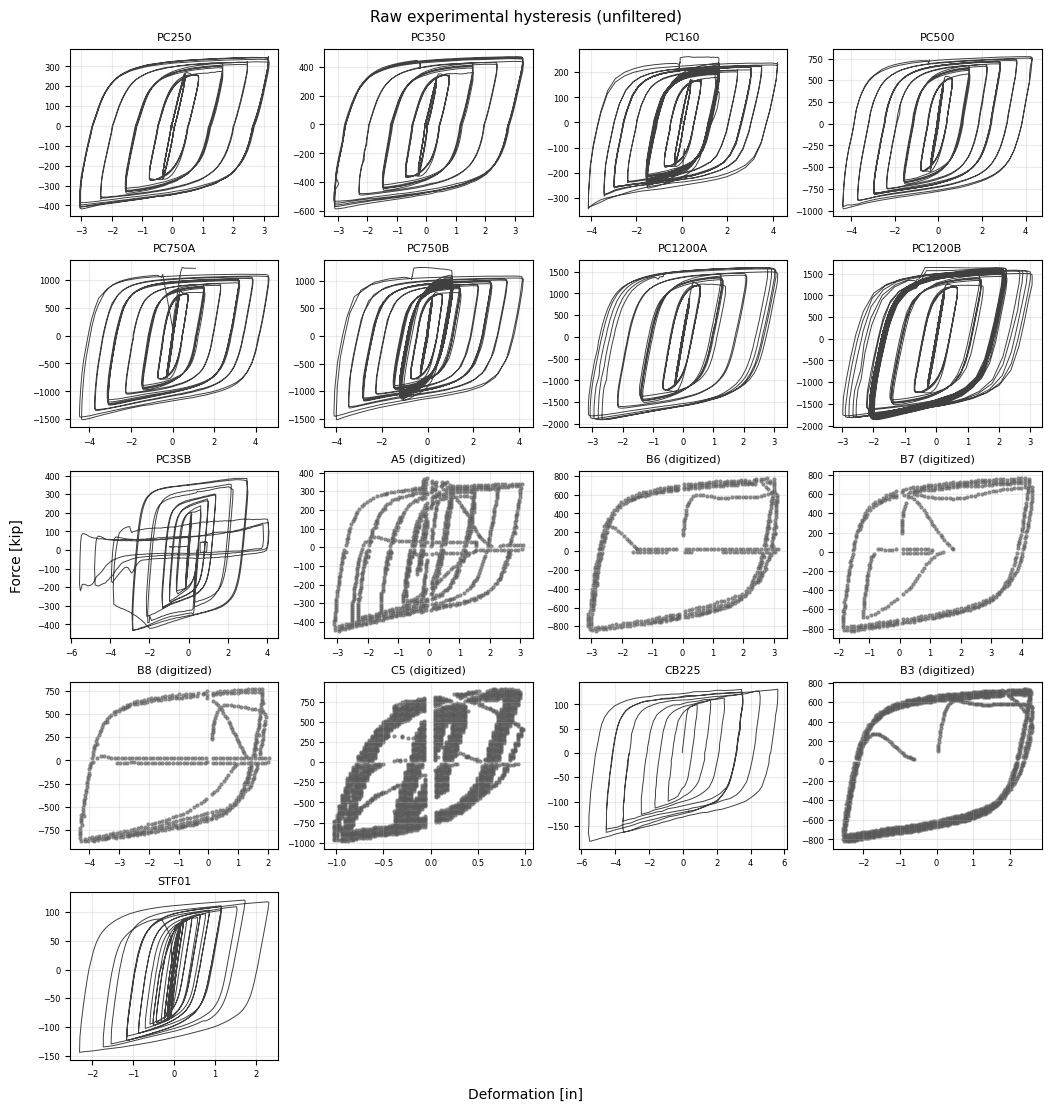

catalog rows: 17


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "scripts" / "examples" / "notebook_support.py").is_file():
    for cand in (ROOT, *ROOT.parents):
        if (cand / "scripts" / "examples" / "notebook_support.py").is_file():
            ROOT = cand
            break
    else:
        raise SystemExit("Could not find BRB-Calibration repo root (need scripts/examples/notebook_support.py).")
import os
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "scripts" / "examples"))
import importlib
import notebook_support
importlib.reload(notebook_support)
from notebook_support import show_specimen_catalog  # noqa: E402

catalog = show_specimen_catalog()
print("catalog rows:", len(catalog))


## What the objective measures

We ask the optimizer to make the model hysteresis look like the experiment.
It does that by minimizing a **weighted sum** of a few error terms:

`J_total = Σ w_k · metric_k`

| Weight | Plain-language meaning |
|--------|------------------------|
| `w_feat_l2` / `w_feat_l1` | How much the fit weights L2 vs L1 error on the **important points** of each cycle (peaks, unload, re-yield). Demos usually put all the weight on one (set it to 1, the other to 0). |
| `w_energy_l2` / `w_energy_l1` | How well per-cycle **energy** (abs of `∫ F du`) matches. Usually left at 0. |
| `w_unordered_binenv_l2` / `w_unordered_binenv_l1` | How well the **outer force envelope** matches when you only have a cloud of `(D, F)` points (digitized tests). Usually weight 0 in the fit; still reported as a diagnostic. |

Even when a weight is 0, the metrics tables still **print** that column so you can look at it.

## Amplitude weighting (inside the point-match term)

These settings do **not** add a new term. They only change how cycles are mixed
**inside** the characteristic-point error `J_feat`:

`J_feat = Σ_c w_c · j_c / Σ_c w_c`

| Setting | Effect |
|---------|--------|
| `use_amplitude_weights=False` | Every cycle counts equally (`w_c = 1`). |
| `use_amplitude_weights=True` | Larger cycles count more: `w_c = (A_c / A_max)^p + ε`. |
| `amplitude_weight_power` (`p`) | How strongly amplitude boosts the weight. |
| `amplitude_weight_eps` (`ε`) | Small floor so tiny cycles are not ignored completely. |


## What the calibration settings mean

These notebooks run **one configuration at a time** (one specimen list + one
SteelMPF / loss recipe). The automated pipeline does the same idea over the full
catalog, often with two recipes (e.g. `set_id=1` for L2, `set_id=3` for L1).

| Setting | Meaning |
|---------|---------|
| **`set_id`** | Integer tag for this run so results do not overwrite each other. Example: an L2-based optimization as `set_id=1`, another (L1) as `set_id=3`. |
| **`inherit_from_set`** | `-999` (or blank) = start from the **seeds** below. Otherwise reuse the **optimized parameters** from that other `set_id` as this run’s starting point, then change whatever you want here (loss weights, which params are free, seeds for params that stay fixed, …). |
| **Seeds** (`E`, `b_p`, `b_n`, `R0`, …) | Starting SteelMPF values when you are not inheriting. Parameters **not** listed in `optimize_params` stay fixed at these seeds. Free parameters **start** here (or from the inherited set) and move during L-BFGS-B. |
| **`optimize_params`** | Which SteelMPF names the optimizer may change. Everything else stays at its seed (or inherited value). |
| **`w_feat_l2` / `w_feat_l1`** | How much the objective weights L2 vs L1 error on characteristic points. `1` and `0` means “all L2”; swap them for all L1; both nonzero mixes the two. |
| **`b_p` / `b_n` seeds** | A numeric guess, or a keyword that **extracts** the value from the experimental hysteresis cycles: `median` (across cycles), `mean`, `weighted_mean`, plus `q1`, `q3`, `min`, `max`, … |

### Common edits (copy into the Parameters cell)

**Free a different parameter set**

```python
# Fewer free params (pipeline individual default style):
OPTIMIZE_PARAMS = ["cR1", "cR2", "a1", "a3"]
# More free params (single-specimen / generalized demo style):
# OPTIMIZE_PARAMS = ["b_p", "b_n", "R0", "cR1", "cR2", "a1", "a3"]
```

**Run L2, then L1** (like pipeline `set_id=1` then `set_id=3`)

```python
# set_id = 3          # optional label for outputs
# w_feat_l2 = 0
# w_feat_l1 = 1
```

Run once with L2 / `set_id=1` (the defaults). To add an L1 pass, change the loss
weights and `set_id` to 3 and run again. Optionally set `inherit_from_set=1` on
the second pass so L1 starts from the L2 result.


## Parameters

- **`SPECIMENS`** — list to fit (keep 2–3 for a quick demo; grow the list to mirror
  the pipeline’s multi-specimen individual run).
- **`SET_ID_ROW`** — one shared seed / loss / free-parameter recipe (same idea as
  `config/calibration/set_id_settings.csv`). See the settings help above for
  `set_id`, `inherit_from_set`, seeds, and `optimize_params`.

To mirror the automated L2 then L1 workflow: run once with the defaults below
(`set_id=1`, L2), then switch to the commented L1 block (`set_id=3`) and run again.


In [2]:
from pathlib import Path
import sys

# --- edit these ---
SPECIMENS = ["PC3SB", "PC160", "PC250"]  # keep to 2–3 for a quick demo
PREPARE_DATA = True

# One shared recipe for every specimen in SPECIMENS.
# set_id         -> label on CSVs/plots (1 = L2, 3 = L1 in the pipeline)
# inherit_from_set -> -999 = start from seeds; else start from that set_id's optimized params
# optimize_params  -> which SteelMPF names L-BFGS-B may change
# E, b_p, ...      -> seeds (fixed params stay here; free params start here)
SET_ID_ROW = {
    "set_id": 1,
    "inherit_from_set": -999,
    "E": 29000,
    "b_p": "weighted_mean",  # numeric guess, or extract from cycles: median, mean, weighted_mean, ...
    "b_n": "weighted_mean",
    "R0": 20,
    "cR1": 0.8875,
    "cR2": 0.15,
    "a1": 0.04,
    "a2": 1.0,
    "a3": 0.04,
    "a4": 1.0,
    "optimize_params": ["cR1", "cR2", "a1", "a3"],
    # "optimize_params": ["b_p", "b_n", "R0", "cR1", "cR2", "a1", "a3"],  # freer
    "w_feat_l2": 1,
    "w_feat_l1": 0,
    "w_energy_l2": 0,
    "w_energy_l1": 0,
    "w_unordered_binenv_l2": 0,
    "w_unordered_binenv_l1": 0,
    "use_amplitude_weights": True,
    "amplitude_weight_power": 2,
    "amplitude_weight_eps": 0.05,
}

# --- optional: L1 pass (pipeline set_id=3) — uncomment to replace the block above ---
# SET_ID_ROW = {
#     "set_id": 3,
#     "inherit_from_set": -999,  # or 1 to start from set_id=1, then change weights / free params
#     "E": 29000,
#     "b_p": "weighted_mean",
#     "b_n": "weighted_mean",
#     "R0": 20,
#     "cR1": 0.8875,
#     "cR2": 0.15,
#     "a1": 0.04,
#     "a2": 1.0,
#     "a3": 0.04,
#     "a4": 1.0,
#     "optimize_params": ["cR1", "cR2", "a1", "a3"],
#     "w_feat_l2": 0,
#     "w_feat_l1": 1,
#     "w_energy_l2": 0,
#     "w_energy_l1": 0,
#     "w_unordered_binenv_l2": 0,
#     "w_unordered_binenv_l1": 0,
#     "use_amplitude_weights": True,
#     "amplitude_weight_power": 2,
#     "amplitude_weight_eps": 0.05,
# }
# ------------------

ROOT = Path.cwd().resolve()
if not (ROOT / "scripts" / "examples" / "notebook_support.py").is_file():
    for cand in (ROOT, *ROOT.parents):
        if (cand / "scripts" / "examples" / "notebook_support.py").is_file():
            ROOT = cand
            break
    else:
        raise SystemExit("Could not find BRB-Calibration repo root (need scripts/examples/notebook_support.py).")
import os
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "scripts" / "examples"))
from notebook_support import (  # noqa: E402
    load_experiment_force_disp,
    params_dict_from_row,
    run_individual_specimens,
    simulate_force_disp,
)
print("specimens:", SPECIMENS)
print("set_id:", SET_ID_ROW["set_id"], "inherit_from_set:", SET_ID_ROW["inherit_from_set"])
print("optimize_params:", SET_ID_ROW["optimize_params"])
print("feat weights: L2=", SET_ID_ROW["w_feat_l2"], "L1=", SET_ID_ROW["w_feat_l1"])


specimens: ['PC3SB', 'PC160', 'PC250']
set_id: 1 inherit_from_set: -999
optimize_params: ['cR1', 'cR2', 'a1', 'a3']
feat weights: L2= 1 L1= 0


## Run individual optimize

Fits each specimen on its own (same seeds / loss / free params for all), then
writes overlays so you can compare them side by side.


In [3]:
paths = run_individual_specimens(
    SPECIMENS,
    set_id_row=SET_ID_ROW,
    prepare_data=PREPARE_DATA,
)
print("params:  ", paths["params"])
print("overlays:", paths["overlays_dir"])


Preparing data for 'PC3SB'...
  Preparing data for 'PC3SB'...


    cycle_points: 91 points, 91 segments (wrote JSON)
Skip filtering PC3SB: min segment length 6 < 11


Wrote data\filtered\PC3SB/{force_deformation,deformation_history}.csv
    filter_force: done


  PC3SB: resampled n=2487 (filtered n=99649), D_sampling=0.0282069 in
    resample_filtered: done
Preparing data for 'PC160'...
  Preparing data for 'PC160'...


    cycle_points: 265 points, 265 segments (wrote JSON)


...

+ C:\Users\garaujor\AppData\Local\anaconda3\envs\py312\python.exe C:\Users\garaujor\source\repos\BRB-Calibration\scripts\calibrate\optimize_brb_mse.py --initial-params C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\individual\initial_brb_parameters.csv --set-id-settings C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\individual\set_id_settings.csv --output C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\individual\optimized_brb_parameters.csv


+ C:\Users\garaujor\AppData\Local\anaconda3\envs\py312\python.exe C:\Users\garaujor\source\repos\BRB-Calibration\scripts\calibrate\plot_params_vs_filtered.py --specimen PC3SB --params C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\individual\optimized_brb_parameters.csv --output-dir notebook_individual


+ C:\Users\garaujor\AppData\Local\anaconda3\envs\py312\python.exe C:\Users\garaujor\source\repos\BRB-Calibration\scripts\calibrate\plot_params_vs_filtered.py --specimen PC160 --params C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\individual\optimized_brb_parameters.csv --output-dir notebook_individual


+ C:\Users\garaujor\AppData\Local\anaconda3\envs\py312\python.exe C:\Users\garaujor\source\repos\BRB-Calibration\scripts\calibrate\plot_params_vs_filtered.py --specimen PC250 --params C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\individual\optimized_brb_parameters.csv --output-dir notebook_individual


params:   C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\individual\optimized_brb_parameters.csv
overlays: C:\Users\garaujor\source\repos\BRB-Calibration\results\plots\calibration\individual_optimize\notebook_individual


## Results

For each specimen: load the experiment, rebuild the model force from that
specimen's fitted parameters, and plot. Edit `p` inside the loop if you want to
explore without re-fitting.


,ID,Name,set_id,steel_model,L_T,L_y,A_sc,A_t,fyp,fyn,E,b_p,b_n,R0,cR1,cR2,a1,a2,a3,a4
0,1,PC250,1,steelmpf,251.96,179.4,5.96,59.6,41.3,41.3,29000.0,0.015843,0.027614,20.0,0.868705,0.063540,0.037314,1.0,0.031201,1.0
1,3,PC160,1,steelmpf,252.00,176.0,3.80,38.0,41.3,41.3,29000.0,0.020738,0.035475,20.0,0.919210,1.760597,0.033623,1.0,0.028093,1.0
2,9,PC3SB,1,steelmpf,116.00,78.0,5.00,50.0,40.0,40.0,29000.0,0.010991,0.021606,20.0,0.852328,0.161345,0.030850,1.0,0.030940,1.0


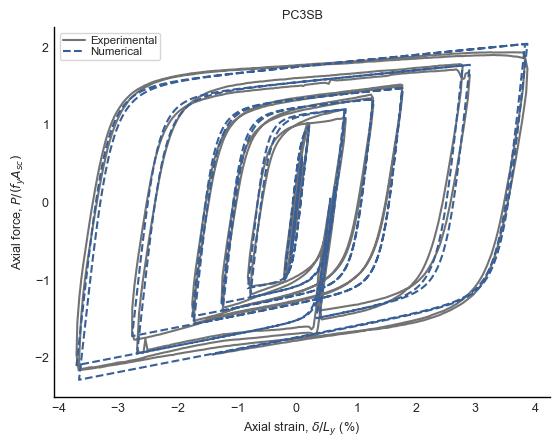

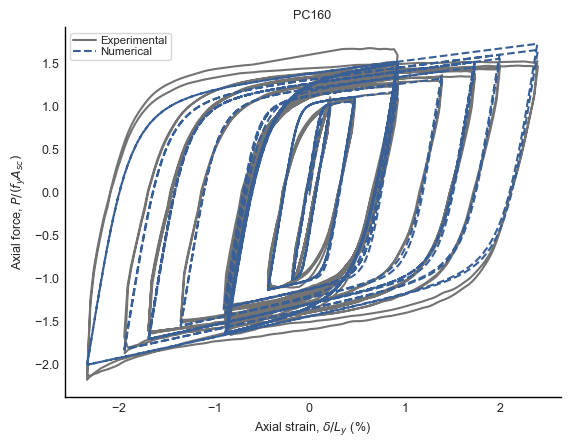

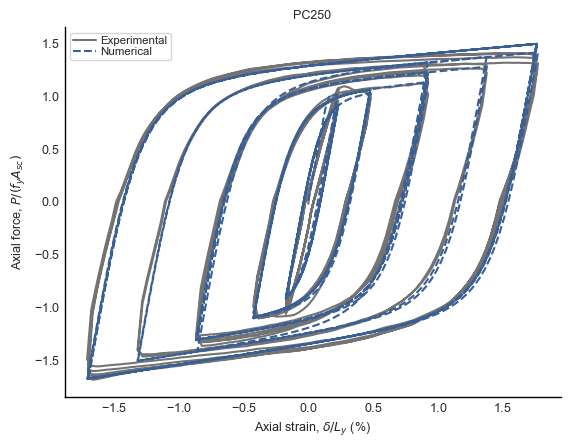

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

params = pd.read_csv(paths["params"])
display(params)

sid = int(SET_ID_ROW["set_id"])
for name in SPECIMENS:
    row = params[(params["Name"].astype(str) == name) & (params["set_id"] == sid)].iloc[0]
    p = params_dict_from_row(row)
    exp_disp, exp_force = load_experiment_force_disp(name)
    num_disp, num_force = simulate_force_disp(exp_disp, **p)

    fyA = p["fyp"] * p["A_sc"]
    plt.figure()
    plt.plot(100.0 * exp_disp / p["L_y"], exp_force / fyA, color="0.45", label="Experimental")
    plt.plot(100.0 * num_disp / p["L_y"], num_force / fyA, linestyle="--", label="Numerical")
    plt.xlabel(r"Axial strain, $\delta / L_y$ (%)")
    plt.ylabel(r"Axial force, $P / (f_y A_{sc})$")
    plt.title(name)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
